<a href="https://colab.research.google.com/github/RichardEager0803/Machine-Learning/blob/main/HW3/churn_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment #3 Experiments & Tasks

Logistic Regression using SGDClassifier



Goals:


*   Source the Telco Customer Churn dataset from Kaggle
*   Inspect its structure


*   Handle implicit missing data
*   Construct an automated preprocessing pipeline using Scikit-Learn


*   Train a **logistic regression** classifier using **SGDClassifier** to predict whether a customer will **churn** (leave the company) or **stay.**








1. Loads the dataset into a Pandas DataFrame (called df).
2. Uses the inspection methods (head(), info(), and describe()) to analyze features.

In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

print("\nHead Method: ")
print(df.head())

print("\nInfo Method: ")
print(df.info())

print("\nDescribe Method: ")
print(df.describe())


Head Method: 
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No     

3. Drops any non-informative identifiers (in this case customer_id), and converts the "TotalCharges" to numeric.

In [2]:
df_clean = df.drop(columns=["customerID"])
df_clean["TotalCharges"] = pd.to_numeric(df_clean["TotalCharges"], errors="coerce")

4. Checks for missing values before pipeline processing.

In [3]:
print("\nMissing values before pipeline execution.")
print(df_clean.isnull().sum())


Missing values before pipeline execution.
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


5. Isolates numeric and categoric features/columns. Then uses Scikit-Learn's SimpleImputer to handle the missing entries. Then with the isolated numerical and categoric features, we can now build the Scikit-Learn ColumnTransformer and Pipeline that applies the appropriate scaling (e.g., StandardScaler or MinMaxScaler) to numerical columns and encoding (e.g., OneHotEncoder) to categorical columns.

6. Appends an SGDClassifier configured with loss='log_loss' to the end of the pipeline to perform logistic regression and enable probability estimation.

7. Splits the dataset into training and test sets using 3 different train/test split ratios (for example, 80/20, 70/30, and 60/40). This fits the complete pipeline on each configuration, and evaluates the performance using a confusion matrix, classification report, and ROC-AUC curve. It also reports on any performance differences detected across the various splitting ratios.

8. Inspects model feature coefficients to interpret how the model separates churning customers from retained customers.


Experiment Using: StandardScaler

--- Evaluation for 80/20 Split (Test Size: 0.2) ---
ROC-AUC Score: 0.8391
Confusion Matrix:
 [[793 242]
 [106 268]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.72      0.61       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg       0.79      0.75      0.76      1409


--- Evaluation for 70/30 Split (Test Size: 0.3) ---
ROC-AUC Score: 0.8401
Confusion Matrix:
 [[1096  456]
 [ 107  454]]
Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.71      0.80      1552
           1       0.50      0.81      0.62       561

    accuracy                           0.73      2113
   macro avg       0.70      0.76      0.71      2113
weighted avg       0.80      0.73      0.75      2113


--- Evaluation for 60/40 

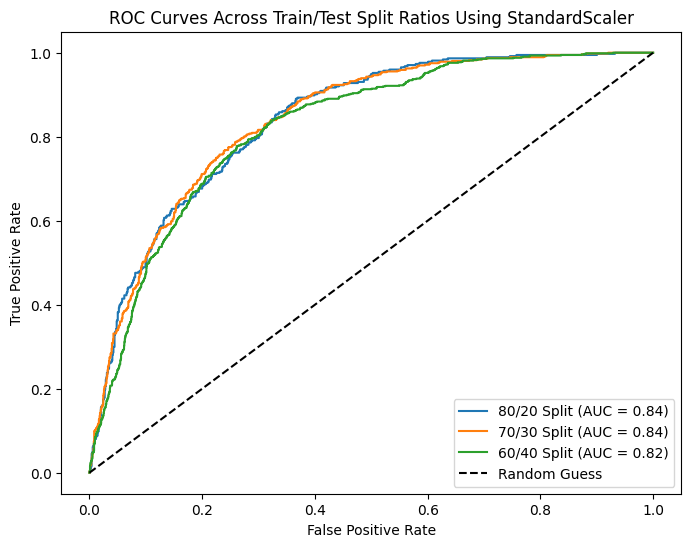


Top 10 Most Influential Features (Positive = Drives Churn, Negative = Retains Customer):
                    Feature  Coefficient
                     tenure    -1.186632
InternetService_Fiber optic     1.125317
    Contract_Month-to-month     1.017550
               TotalCharges     0.852695
             MonthlyCharges    -0.769697
          OnlineSecurity_No     0.628046
        StreamingMovies_Yes     0.615127
           PhoneService_Yes     0.602695
          MultipleLines_Yes     0.587310
          Contract_Two year    -0.539499

Experiment Using: MinMaxScaler

--- Evaluation for 80/20 Split (Test Size: 0.2) ---
ROC-AUC Score: 0.8277
Confusion Matrix:
 [[797 238]
 [109 265]]
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.77      0.82      1035
           1       0.53      0.71      0.60       374

    accuracy                           0.75      1409
   macro avg       0.70      0.74      0.71      1409
weighted avg  

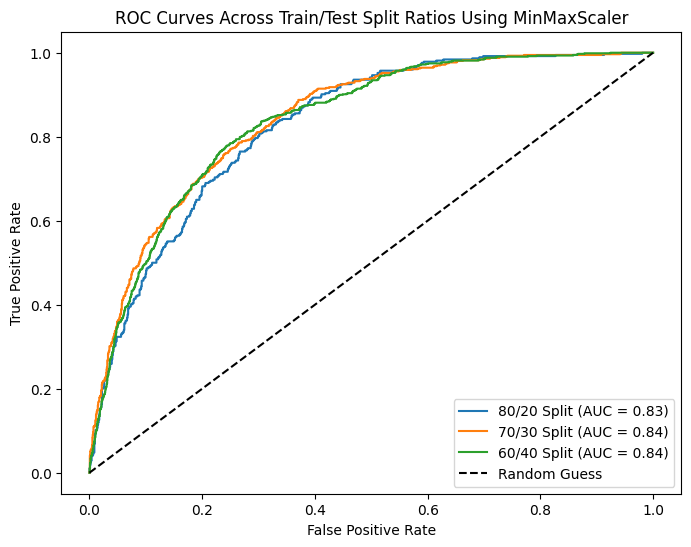


Top 10 Most Influential Features (Positive = Drives Churn, Negative = Retains Customer):
                    Feature  Coefficient
                     tenure    -3.289506
               TotalCharges     1.843777
    Contract_Month-to-month     0.880267
InternetService_Fiber optic     0.689598
          Contract_Two year    -0.595939
          OnlineSecurity_No     0.532093
             MonthlyCharges    -0.514968
            OnlineBackup_No     0.381719
          MultipleLines_Yes     0.360922
        StreamingMovies_Yes     0.340697


In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import seaborn as sns
import matplotlib.pyplot as plt

# Isolating numeric, categoric, and target columns
numeric_cols = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges",
    "SeniorCitizen"
]

categoric_cols = []
for col in df_clean.columns:
    if col not in numeric_cols and col != "Churn" and col != "SeniorCitizen":
        categoric_cols.append(col)

target_col = "Churn"

X = df_clean[numeric_cols + categoric_cols]
y = df["Churn"].map({"Yes": 1, "No": 0})

# Comparing StandardScaler and MinMaxScaler
scalers = {
    "StandardScaler": StandardScaler(),
    "MinMaxScaler": MinMaxScaler()
}

# Also experimenting with different train/test ratios
ratios = {
    "80/20 Split": 0.20,
    "70/30 Split": 0.30,
    "60/40 Split": 0.40
}

for scaler_name, scaler_instance in scalers.items():
    print(f"\nExperiment Using: {scaler_name}")

    numeric_transformer = Pipeline(
        steps = [
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", scaler_instance),
        ]
    )

    categorical_transformer = Pipeline(
        steps = [
            ("imputer", SimpleImputer(strategy="constant", fill_value="None")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers = [
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categoric_cols),
        ]
    )

    sgd_logistic_model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", SGDClassifier(
            loss="log_loss",
            penalty="l2",
            alpha=0.0001,
            class_weight="balanced",
            max_iter=1000,
            random_state=42
        ))
    ])

    plt.figure(figsize=(8, 6))

    for label, test_size in ratios.items():
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_size, random_state=42, stratify=y
        )

        sgd_logistic_model.fit(X_train, y_train)

        y_pred = sgd_logistic_model.predict(X_test)
        y_prob = sgd_logistic_model.predict_proba(X_test)[:, 1]

        auc = roc_auc_score(y_test, y_prob)
        print(f"\n--- Evaluation for {label} (Test Size: {test_size}) ---")
        print(f"ROC-AUC Score: {auc:.4f}")
        print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
        print("Classification Report:\n", classification_report(y_test, y_pred))

        # Plots ROC curve for comparison
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        plt.plot(fpr, tpr, label=f"{label} (AUC = {auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--', label="Random Guess")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curves Across Train/Test Split Ratios Using {scaler_name}")
    plt.legend(loc="lower right")
    plt.show()

    # Extracts feature names after OneHotEncoding
    cat_encoder = sgd_logistic_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
    encoded_cat_cols = cat_encoder.get_feature_names_out(categoric_cols).tolist()
    all_feature_names = numeric_cols + encoded_cat_cols

    # Extracts coefficients from the SGDClassifier
    coefficients = sgd_logistic_model.named_steps['classifier'].coef_[0]

    # Creates the summary dataframe
    coef_df = pd.DataFrame({"Feature": all_feature_names, "Coefficient": coefficients})
    coef_df["Abs_Coefficient"] = coef_df["Coefficient"].abs()
    coef_df = coef_df.sort_values(by="Abs_Coefficient", ascending=False)

    print("\nTop 10 Most Influential Features (Positive = Drives Churn, Negative = Retains Customer):")
    print(coef_df[["Feature", "Coefficient"]].head(10).to_string(index=False))